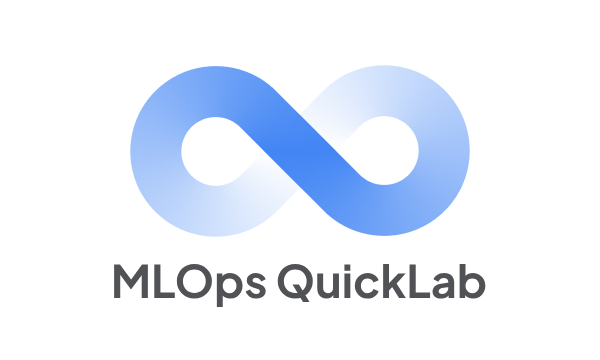

7. Vertex AI - 빅데이터를 이용한 모델 학습 및 배포

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

In [5]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

## Kaggle로 부터 데이터셋 준비
https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data 데이터셋 활용
위 데이터셋은 유저 `Cust_Id`의 영화 `Movie_Id` 시청에 따른 호응도 `Rating` 정보가 포함되어있음.

**데이터 형태**

Item | Description
-----|-------------
특징 | 시계열 데이터 (Time series)
전체 크기 | 100 ,480,507
영화 수 | 17,770

In [6]:
!pip install kaggle
!kaggle datasets download -d netflix-inc/netflix-prize-data
!unzip "netflix-prize-data.zip" -d netflix-prize-data

Dataset URL: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data
License(s): other
100% 683M/683M [00:04<00:00, 169MB/s]

Archive:  netflix-prize-data.zip
  inflating: netflix-prize-data/README  
  inflating: netflix-prize-data/combined_data_1.txt  
  inflating: netflix-prize-data/combined_data_2.txt  
  inflating: netflix-prize-data/combined_data_3.txt  
  inflating: netflix-prize-data/combined_data_4.txt  
  inflating: netflix-prize-data/movie_titles.csv  
  inflating: netflix-prize-data/probe.txt  
  inflating: netflix-prize-data/qualifying.txt  


In [7]:
!head netflix-prize-data/combined_data_1.txt

1:
1488844,3,2005-09-06
822109,5,2005-05-13
885013,4,2005-10-19
30878,4,2005-12-26
823519,3,2004-05-03
893988,3,2005-11-17
124105,4,2004-08-05
1248029,3,2004-04-22
1842128,4,2004-05-09


In [8]:
!ls -alh netflix-prize-data | grep combined_data

-rw-r--r-- 1 root root 473M Nov 13  2019 combined_data_1.txt
-rw-r--r-- 1 root root 530M Nov 13  2019 combined_data_2.txt
-rw-r--r-- 1 root root 444M Nov 13  2019 combined_data_3.txt
-rw-r--r-- 1 root root 527M Nov 13  2019 combined_data_4.txt


## 데이터 전처리

1억개 전체 데이터로 학습을 돌리면, 매 Epoch당 약 6시간의 학습 시간이 요구되어
Epoch 당 약 10분의 학습 시간을 유도하기 위해 User 기준으로 `1 / 30` Ratio 비중으로 샘플링 수행.

In [9]:
def load_netflix_data(data_dir: str) -> pd.DataFrame:
    files = [
        os.path.join(data_dir, f)
        for f in [
            "combined_data_1.txt",
            "combined_data_2.txt",
            "combined_data_3.txt",
            "combined_data_4.txt",
        ]
    ]
    data = pd.DataFrame()

    for file in files:
        df = pd.read_csv(file, header=None, names=["Cust_Id", "Rating", "Date"], usecols=[0, 1, 2])
        df["Rating"] = df["Rating"].astype(float)
        df["Movie_Id"] = (
            df["Cust_Id"]
            .apply(lambda x: x[:-1] if ":" in x else np.nan)
            .ffill()
            .astype(int)
        )
        df = df[df["Rating"].notna()]
        data = pd.concat([data, df])

    sample_fraction = 1 / 30.0
    sampled_users = random.sample(data["Cust_Id"].unique().tolist(),
                                    int(len(data["Cust_Id"].unique()) * sample_fraction))
    sampled_data = data[data["Cust_Id"].isin(sampled_users)]

    return sampled_data

## 모델 정의
모델은 `Rating`을 GT(Ground Truth) 데이터로 사용하여 예측하는 문제.

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [12]:
from typing import Tuple
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class NetflixDataset(Dataset):
    def __init__(self, data: pd.DataFrame, seq_len: int = 10):
        """
        data: Cust_Id, Movie_Id, Rating, Date 등의 열을 가진 DataFrame
        seq_len: 시퀀스 길이
        """
        self.seq_len = seq_len
        # 유저별 데이터 그룹핑 후 시퀀스 생성
        self.data = data.groupby("Cust_Id").apply(self._create_sequences).reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.data)

    def _create_sequences(self, user_data: pd.DataFrame) -> pd.DataFrame:
        # 날짜 기준으로 정렬
        user_data = user_data.sort_values(by="Date")

        # i:i+seq_len 윈도우로 Movie_Id, Rating을 시퀀스로 구성
        sequences = [
            (
                user_data["Movie_Id"].values[i:i+self.seq_len],
                user_data["Rating"].values[i:i+self.seq_len],
            )
            for i in range(len(user_data) - self.seq_len + 1)  # seq_len 길이를 만족하는 마지막 인덱스까지
        ]

        return pd.DataFrame(sequences, columns=["Movie_Sequence", "Rating_Sequence"])

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        movies = torch.tensor(self.data.iloc[idx]["Movie_Sequence"], dtype=torch.long)
        ratings = torch.tensor(self.data.iloc[idx]["Rating_Sequence"], dtype=torch.float)

        return movies, ratings

In [13]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

In [14]:
# Load data
data_dir = "netflix-prize-data"
data = load_netflix_data(data_dir)

In [15]:
# Process data
dataset = NetflixDataset(data)
data_loader = DataLoader(dataset, batch_size=512, shuffle=True)

/tmp/ipykernel_1001/3976683065.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.data = data.groupby("Cust_Id").apply(self._create_sequences).reset_index(drop=True)


In [16]:
num_movies = data["Movie_Id"].max()
model = RecommendationNetwork(num_movies=num_movies, emb_size=100).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
def calculate_accuracy(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    # 평점을 반올림하여 정확도 계산 (정수 평점 가정)
    y_pred_rounded = torch.round(y_pred)
    correct_predictions = (y_pred_rounded == y_true).float().sum()
    accuracy = correct_predictions / y_true.shape[0]
    return accuracy.item()

In [18]:
loss_values: list[float] = []
accuracy_values: list[float] = []
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0
    count_batches = 0

    for movies, ratings in tqdm(data_loader):
        movies = movies.to(device)     # (batch_size, seq_len)
        ratings = ratings.to(device)   # (batch_size, seq_len)

        # 마지막 영화에 대한 평점 예측을 목표로 한다고 가정
        target = ratings[:, -1]  # 시퀀스의 마지막 평점을 타겟으로
        optimizer.zero_grad()
        outputs = model(movies)  # (batch_size,)

        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        accuracy = calculate_accuracy(outputs, target)
        total_loss += loss.item()
        total_accuracy += accuracy
        count_batches += 1

    avg_loss = total_loss / count_batches
    avg_accuracy = total_accuracy / count_batches
    loss_values.append(avg_loss)
    accuracy_values.append(avg_accuracy)
    print(f"Epoch {epoch+1}: Loss = {avg_loss}, Accuracy = {avg_accuracy}")

100%|██████████| 6111/6111 [05:00<00:00, 20.30it/s]


Epoch 1: Loss = 1.0684079427636015, Accuracy = 0.36098895690734134


100%|██████████| 6111/6111 [04:56<00:00, 20.63it/s]


Epoch 2: Loss = 1.0148129388287657, Accuracy = 0.37206976916723294


100%|██████████| 6111/6111 [04:55<00:00, 20.66it/s]


Epoch 3: Loss = 0.9930030876964775, Accuracy = 0.3765705541237113


100%|██████████| 6111/6111 [04:58<00:00, 20.47it/s]


Epoch 4: Loss = 0.9781188182794917, Accuracy = 0.3794492002137065


100%|██████████| 6111/6111 [04:56<00:00, 20.63it/s]

Epoch 5: Loss = 0.966128397653115, Accuracy = 0.3818850612615021


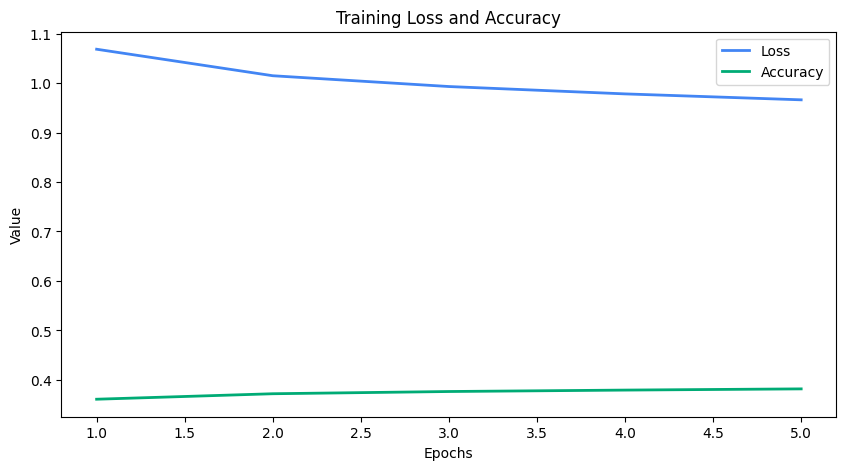

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), loss_values, label="Loss", color="#4285f4", linewidth=2)
plt.plot(range(1, num_epochs+1), accuracy_values, label="Accuracy", color="#00ab75", linewidth=2)
plt.title("Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.show()

## Inference

In [20]:
%%writefile model.py
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

Writing model.py


In [21]:
%%writefile handler.py
import logging
from ts.torch_handler.base_handler import BaseHandler
import torch
from model import RecommendationNetwork

logging.basicConfig(level=logging.INFO)

class NetflixRecommendation(BaseHandler):
    def initialize(self, context):
        properties = context.system_properties
        model_dir = properties.get("model_dir")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # self.num_movies = 17770
        self.num_movies = 9210
        # 가변 길이를 지원하는 모델이므로 seq_len을 고정하지 않습니다.
        self.model = RecommendationNetwork(num_movies=self.num_movies, emb_size=100)
        model_path = model_dir + "/model.pth"
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()

    def preprocess(self, data):
        """
        data 예: [[{"movies": [m1, ..., mN]}], [{"movies": [...]}, ...]]
        """
        logging.info("preprocess input: %s", data)

        # 요청 구조 기록
        self.batch_structure = [len(batch) for batch in data]

        sequences = []
        for batch in data:
            for row in batch:
                movie_seq = row["movies"]
                # 가변 길이 시퀀스를 지원하므로, 길이 검사를 제거합니다.
                sequences.append(movie_seq)

        # 패딩 필요 여부에 따라 처리할 수 있습니다.
        # Transformer에 바로 넣으려면 패딩과 마스크 처리 필요.
        # 여기서는 단순히 텐서 변환(가장 긴 시퀀스에 맞춰 패딩 필요)
        # 예: padding 처리
        max_len = max(len(seq) for seq in sequences)
        padded_sequences = [seq + [0]*(max_len - len(seq)) for seq in sequences]

        movies_tensor = torch.tensor(padded_sequences, dtype=torch.long, device=self.device)
        self.max_len = max_len  # postprocessing할 때는 필요없지만, inference에서 사용할 수 있음

        return movies_tensor

    def inference(self, data):
        """
        data: (total_batch_size, max_seq_len) 텐서 (패딩된 형태)
        """
        logging.info("inference data shape: %s", data.shape)
        with torch.no_grad():
            outputs = self.model(data)  # (total_batch_size,) 형태
        return outputs.tolist()

    def postprocess(self, inference_output):
        """
        inference_output: flat list of predictions
        """
        logging.info("postprocess output: %s", inference_output)

        final_output = []
        idx = 0
        for size in self.batch_structure:
            batch_preds = inference_output[idx:idx+size]
            idx += size
            final_output.append(batch_preds)
        return final_output

Writing handler.py


In [22]:
torch.save(model.state_dict(), "model.pth")

In [23]:
# 가상의 Context 클래스 정의 (TorchServe context 모사)
class Context:
    def __init__(self):
        self.system_properties = {
            "model_dir": "."
        }


context = Context()

In [24]:
!pip install torchserve torch-model-archiver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 MB 37.2 MB/s eta 0:00:00


In [25]:
from handler import NetflixRecommendation

# 핸들러 인스턴스화 및 초기화
netflix_recommendation = NetflixRecommendation()
netflix_recommendation.initialize(Context())

# 샘플 입력: seq_len=10 짜리 영화 시퀀스
sample_input = {"movies": [123, 456, 789, 100, 101, 102, 103, 104, 105, 106]}

# TorchServe 표준 입력 형태: [[sample_input]]
preprocessed = netflix_recommendation.preprocess([[sample_input]])
predicted_rating = netflix_recommendation.inference(preprocessed)
result = netflix_recommendation.postprocess(predicted_rating)

print(f"Predicted Rating: {result}")

Predicted Rating: [[3.1401045322418213]]


## Register to Vertex AI

In [26]:
!torch-model-archiver \
    --model-name model \
    --version 1.0 \
    --model-file model.py \
    --serialized-file model.pth \
    --handler handler.py \
    --export-path . \
    --force

In [27]:
%%writefile config.properties
inference_address=http://0.0.0.0:9080
management_address=http://0.0.0.0:9081
metrics_address=http://0.0.0.0:9082
disable_system_metrics=true
number_of_netty_threads=32
job_queue_size=1000
model_store=/home/model-server/model-store

Writing config.properties


In [ ]:
# # for testing
# !torchserve \
#     --start \
#     --model-store ./ \
#     --models recommendation=model.mar \
#     --ts-config config.properties

# curl http://localhost:9080/ping

In [28]:
from google.cloud import storage, aiplatform
from google.oauth2 import service_account

In [ ]:
# from google.colab import auth
# auth.authenticate_user()

In [30]:
credentials = service_account.Credentials.from_service_account_file("credentials.json")

In [51]:
PROJECT_ID = "mlops-493303"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-0422"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [52]:
storage_client = storage.Client(credentials=credentials)
bucket = storage_client.bucket(BUCKET_NAME)

In [53]:
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [54]:
upload_blob("model.mar", f"models/{MODEL_FILE_NAME}")

File model.mar uploaded to models/model.mar.


In [55]:
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    credentials=credentials,
)

In [66]:
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="Netflix Recommender",
    artifact_uri=model_path,
    # serving_container_image_uri="asia-northeast3-docker.pkg.dev/gde-project-aicloud/mlops-quicklab/trainer:1.0.3",
    serving_container_image_uri="asia-northeast3-docker.pkg.dev/mlops-493303/mlops-quicklab/trainer:1.0.0",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A netflix rating classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

In [67]:
DEPLOY_COMPUTE = "n1-standard-2"
# DEPLOY_COMPUTE = "n1-highmem-4"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [68]:
endpoint = aiplatform.Endpoint.create(
    display_name="netflix-recommendation",
    project=PROJECT_ID,
    location=LOCATION,
)

In [69]:
deployment = registry_model.deploy(
    endpoint=endpoint,
    machine_type=DEPLOY_COMPUTE,
    min_replica_count=1,
    max_replica_count=1,
    accelerator_type=DEPLOY_ACCELERATOR,
    accelerator_count=1,
    traffic_percentage=100,
    sync=True,
)

In [70]:
instances = [{"movies": [100, 101, 102, 103, 104, 105, 106, 107, 108, 400]}]
endpoint.predict(instances=[instances])

Prediction(predictions=[[2.786695003509521]], deployed_model_id='6082702834019598336', metadata=None, model_version_id='1', model_resource_name='projects/772792024339/locations/asia-northeast3/models/3607730747198144512', explanations=None)

## Clean up

In [71]:
endpoint.undeploy_all()
endpoint.delete()

In [72]:
registry_model.delete()